# ResNet50 with attention    
## Binary DR Detection (당뇨병성 망막병증 이진 분류 모델)
###dataset_1_ver4
###**kaggle data(APTOS 2019) 검증**

---

**APTOS 2019 데이터 구조:**
- 3,662 images

Class Distribution (Original):
- 0 (No DR):           1,805 (49.3%)
- 1 (Mild):             370 (10.1%)
- 2 (Moderate):         999 (27.3%)
- 3 (Severe):           193 (5.3%)
- 4 (Proliferative):    295 (8.1%)

Binary 변환 가능:
- 0 → No DR:          1,805 (49.3%)
- 1-4 → DR:           1,857 (50.7%)



In [ ]:
# google mount

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from torchvision import models
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
# ==============================================================================
# 1. 경로 설정 (⚠️ 본인 경로로 수정!)
# ==============================================================================

# ResNet-50 학습 모델
MODEL_PATH = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet-50_Attention/ver4/best_model_recall.pth'

# APTOS 2019 데이터 (Kaggle에서 가져온 것)
APTOS_BASE = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/kaggle'
APTOS_CSV = os.path.join(APTOS_BASE, 'manifest_test.csv')
APTOS_IMG_DIR = os.path.join(APTOS_BASE, 'test')

# 결과 저장
OUTPUT_DIR = os.path.join(APTOS_BASE, 'ver4')
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# ==============================================================================
# 2. 파일 존재 확인
# ==============================================================================

print(f"\n{'='*80}")
print("📂 Checking Files...")
print(f"{'='*80}")

files_ok = True

if os.path.exists(MODEL_PATH):
    print(f"✅ Model: {MODEL_PATH}")
else:
    print(f"❌ Model NOT FOUND: {MODEL_PATH}")
    files_ok = False

if os.path.exists(APTOS_CSV):
    print(f"✅ CSV: {APTOS_CSV}")
    # CSV 미리보기
    df_check = pd.read_csv(APTOS_CSV)
    print(f"   Columns: {list(df_check.columns)}")
    print(f"   Rows: {len(df_check)}")
else:
    print(f"❌ CSV NOT FOUND: {APTOS_CSV}")
    files_ok = False

if os.path.exists(APTOS_IMG_DIR):
    print(f"✅ Images: {APTOS_IMG_DIR}")
    img_files = [f for f in os.listdir(APTOS_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"   → {len(img_files)} images found")
else:
    print(f"❌ Images NOT FOUND: {APTOS_IMG_DIR}")
    files_ok = False

if not files_ok:
    raise FileNotFoundError("Some files are missing! Please check paths.")

print(f"{'='*80}\n")



📂 Checking Files...
✅ Model: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet-50_Attention/ver4/best_model_recall.pth
✅ CSV: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/kaggle/manifest_test.csv
   Columns: ['img_id', 'label']
   Rows: 550
✅ Images: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/kaggle/test
   → 550 images found



In [ ]:
# ==============================================================================
# 3. Dataset
# ==============================================================================

class APTOSDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        # CSV 컬럼 확인 및 처리
        if 'label' in self.df.columns:
            label_col = 'label'
        elif 'diagnosis' in self.df.columns:
            self.df['label'] = (self.df['diagnosis'] > 0).astype(int)
            label_col = 'label'
        else:
            raise ValueError("CSV must have 'label' or 'diagnosis' column")

        # 이미지 ID 컬럼 확인
        if 'img_id' in self.df.columns:
            self.id_col = 'img_id'
        elif 'id_code' in self.df.columns:
            self.id_col = 'id_code'
        elif 'image' in self.df.columns:
            self.id_col = 'image'
        else:
            self.id_col = self.df.columns[0]

        print(f"\n📊 APTOS Dataset:")
        print(f"   CSV Columns: {list(self.df.columns)}")
        print(f"   Image ID Column: {self.id_col}")
        print(f"   Total: {len(self.df)}")
        print(f"   No DR (0): {(self.df[label_col]==0).sum()} ({(self.df[label_col]==0).sum()/len(self.df)*100:.1f}%)")
        print(f"   DR (1):    {(self.df[label_col]==1).sum()} ({(self.df[label_col]==1).sum()/len(self.df)*100:.1f}%)")

        if 'diagnosis' in self.df.columns:
            print(f"\n   Original Grade Distribution:")
            for grade in range(5):
                count = (self.df['diagnosis'] == grade).sum()
                if count > 0:
                    print(f"     Grade {grade}: {count} ({count/len(self.df)*100:.1f}%)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])
        label = float(row['label'])

        # 이미지 로드 (다양한 확장자 시도)
        img_path = None
        for ext in ['.png', '.jpg', '.jpeg', '']:
            potential_path = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(potential_path):
                img_path = potential_path
                break

        # ⭐ 이미지 없으면 None 반환 (skip 처리)
        if img_path is None:
            return None

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # 로드 실패하면 None 반환
            return None

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


def collate_fn_skip_none(batch):
    """
    None 값 제거하는 collate function
    """
    # None 제거
    batch = [item for item in batch if item is not None]

    if len(batch) == 0:
        return None

    # 일반 collate
    images = torch.stack([item[0] for item in batch])
    labels = torch.stack([item[1] for item in batch])

    return images, labels

In [ ]:
# ==============================================================================
# 4. Model: ResNet-50 with Attention
# ==============================================================================

class AttentionModule(nn.Module):
    """Attention Mechanism"""
    def __init__(self, in_channels):
        super(AttentionModule, self).__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, kernel_size=1),
            nn.BatchNorm2d(in_channels // 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, kernel_size=1),
            nn.BatchNorm2d(in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        att = self.attention(x)
        return x * att


class ResNet50Attention_BinaryDR(nn.Module):
    """ResNet-50 with Attention for Binary DR Classification"""
    def __init__(self, pretrained=True):
        super(ResNet50Attention_BinaryDR, self).__init__()

        # ResNet-50 backbone
        resnet = models.resnet50(pretrained=pretrained)

        # Remove original FC layer
        self.features = nn.Sequential(*list(resnet.children())[:-2])

        # Attention module
        self.attention = AttentionModule(2048)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
# ==============================================================================
# 5. 평가 함수
# ==============================================================================

def evaluate(model, dataloader, device):
    """모델 평가 (None skip 처리)"""
    model.eval()
    all_preds = []
    all_labels = []

    skipped = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            if batch is None:
                skipped += 1
                continue

            images, labels = batch
            images = images.to(device)
            outputs = model(images).squeeze(1)
            probs = torch.sigmoid(outputs)

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    if skipped > 0:
        print(f"\n⚠️ Skipped {skipped} batches (images not found or failed to load)")

    return np.array(all_preds), np.array(all_labels)


def compute_metrics(labels, probs, threshold=0.5):
    """메트릭 계산"""
    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'specificity': specificity,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

In [ ]:
# ==============================================================================
# 6. 시각화
# ==============================================================================

def plot_results(aptos_metrics, rfmid_metrics, output_dir):
    """결과 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix
    cm = aptos_metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No DR', 'DR'], yticklabels=['No DR', 'DR'],
                cbar_kws={'label': 'Count'})
    axes[0].set_title('APTOS 2019 - ResNet-50 with Attention\nConfusion Matrix',
                     fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # 2. Metrics 비교
    metric_names = ['Recall', 'Precision', 'Specificity', 'F1', 'AUC']
    rfmid_values = [
        rfmid_metrics['recall'], rfmid_metrics['precision'],
        rfmid_metrics['specificity'], rfmid_metrics['f1'], rfmid_metrics['auc']
    ]
    aptos_values = [
        aptos_metrics['recall'], aptos_metrics['precision'],
        aptos_metrics['specificity'], aptos_metrics['f1'], aptos_metrics['auc']
    ]

    x = np.arange(len(metric_names))
    width = 0.35

    axes[1].bar(x - width/2, rfmid_values, width, label='RFMiD Test', alpha=0.8, color='#1f77b4')
    axes[1].bar(x + width/2, aptos_values, width, label='APTOS 2019', alpha=0.8, color='#ff7f0e')
    axes[1].axhline(y=0.85, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Target (85%)')

    axes[1].set_ylabel('Score')
    axes[1].set_title('Performance Comparison\nResNet-50 with Attention',
                     fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metric_names)
    axes[1].legend()
    axes[1].set_ylim([0, 1.05])
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(output_dir, 'aptos2019_validation_results.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Plot saved: {save_path}")
    plt.show()


🌍 APTOS 2019 EXTERNAL VALIDATION - ResNet-50 with Attention

📊 APTOS Dataset:
   CSV Columns: ['img_id', 'label']
   Image ID Column: img_id
   Total: 550
   No DR (0): 271 (49.3%)
   DR (1):    279 (50.7%)

📂 Loading ResNet-50 with Attention Model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully!
   Model: ResNet-50 with Attention
   Parameters: 25,613,121

📊 Model Info (RFMiD Training):
   Best Epoch: 7
   Val Recall: 0.9621
   Val AUC: 0.9740
   Val Accuracy: 0.8562
   Val Precision: 0.5935

🚀 Evaluating on APTOS 2019...


Evaluating: 100%|██████████| 35/35 [08:47<00:00, 15.06s/it]



📊 Evaluated 550 samples

📊 APTOS 2019 PERFORMANCE (External Validation)
   Model: ResNet-50 with Attention
Samples:     550
Accuracy:    0.9455
Precision:   0.9770
Recall:      0.9140 ✅ (Target achieved!)
F1 Score:    0.9444
Specificity: 0.9779
AUC:         0.9885

📊 Confusion Matrix:
[[265   6]
 [ 24 255]]

TN=265, FP=6, FN=24, TP=255
False Negative Rate: 8.60% (24 patients missed)
False Positive Rate: 2.21% (6 false alarms)

📊 INTERNAL vs EXTERNAL VALIDATION (ResNet-50)

Metric          RFMiD Test      APTOS 2019      Difference     
--------------------------------------------------------------------------------
Recall          0.8800          0.9140          +0.0340
Precision       0.7200          0.9770          +0.2570
AUC             0.9650          0.9885          +0.0235
Specificity     0.9000          0.9779          +0.0779
F1 Score        0.7900          0.9444          +0.1544

✅ GENERALIZATION EVALUATION
✅ APTOS Recall ≥ 85%: Excellent external validation!
✅ Recall gap <

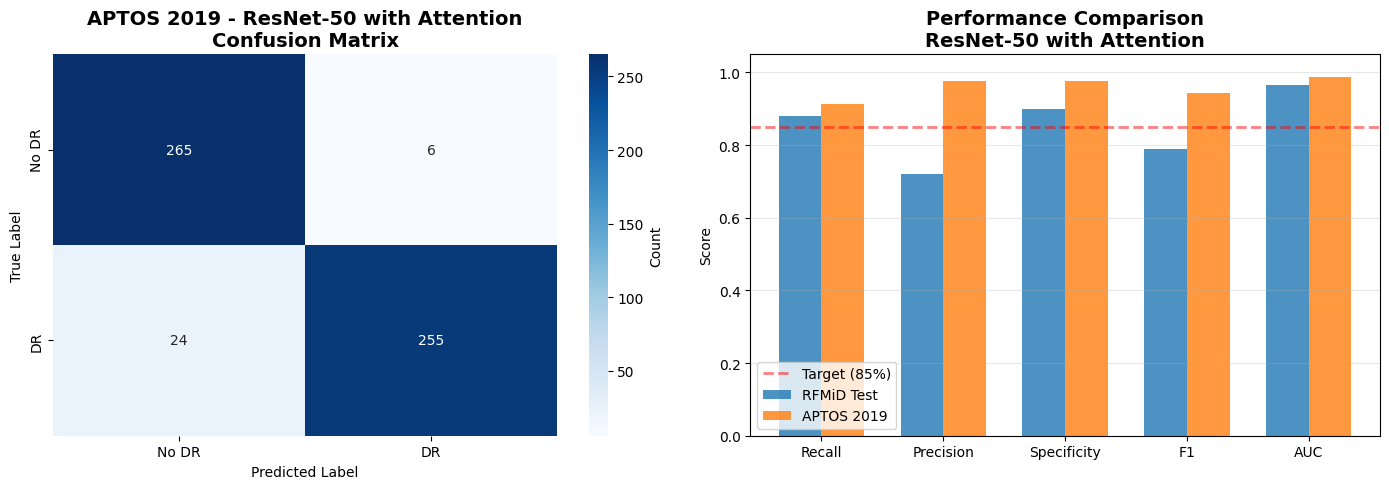

✅ CSV saved: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/kaggle/ver4/aptos2019_validation_results.csv
✅ JSON saved: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/kaggle/ver4/aptos2019_detailed_results.json

🎉 EXTERNAL VALIDATION COMPLETE! (ResNet-50 with Attention)

📊 Summary:
   Model: ResNet-50 with Attention
   Evaluated: 550 samples
   RFMiD Test Recall:  88.00%
   APTOS Recall:       91.40%
   Generalization Gap: 3.40%

🏆 EXCELLENT! Model generalizes well to external data!


In [ ]:
# ==============================================================================
# 7. 메인 실행
# ==============================================================================

def main():
    print("\n" + "="*80)
    print("🌍 APTOS 2019 EXTERNAL VALIDATION - ResNet-50 with Attention")
    print("="*80)

    # 1. Dataset 준비
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    aptos_dataset = APTOSDataset(APTOS_CSV, APTOS_IMG_DIR, transform)

    # ⭐ collate_fn으로 None skip 처리
    aptos_loader = DataLoader(
        aptos_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn_skip_none
    )

    # 2. 모델 로드
    print(f"\n📂 Loading ResNet-50 with Attention Model...")
    model = ResNet50Attention_BinaryDR(pretrained=False)
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    # 모델 파라미터 확인
    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ Model loaded successfully!")
    print(f"   Model: ResNet-50 with Attention")
    print(f"   Parameters: {total_params:,}")

    print(f"\n📊 Model Info (RFMiD Training):")
    print(f"   Best Epoch: {checkpoint['epoch']}")
    print(f"   Val Recall: {checkpoint['val_recall']:.4f}")
    print(f"   Val AUC: {checkpoint['val_auc']:.4f}")
    print(f"   Val Accuracy: {checkpoint['val_accuracy']:.4f}")
    print(f"   Val Precision: {checkpoint['val_precision']:.4f}")

    # 3. APTOS 평가
    print(f"\n🚀 Evaluating on APTOS 2019...")
    aptos_probs, aptos_labels = evaluate(model, aptos_loader, device)

    print(f"\n📊 Evaluated {len(aptos_labels)} samples")

    aptos_metrics = compute_metrics(aptos_labels, aptos_probs, threshold=0.5)

    # 4. 결과 출력
    print("\n" + "="*80)
    print("📊 APTOS 2019 PERFORMANCE (External Validation)")
    print("   Model: ResNet-50 with Attention")
    print("="*80)
    print(f"Samples:     {len(aptos_labels)}")
    print(f"Accuracy:    {aptos_metrics['accuracy']:.4f}")
    print(f"Precision:   {aptos_metrics['precision']:.4f}")
    print(f"Recall:      {aptos_metrics['recall']:.4f}", end="")
    if aptos_metrics['recall'] >= 0.85:
        print(" ✅ (Target achieved!)")
    else:
        print(f" ⚠️ (Gap: {0.85 - aptos_metrics['recall']:.4f})")
    print(f"F1 Score:    {aptos_metrics['f1']:.4f}")
    print(f"Specificity: {aptos_metrics['specificity']:.4f}")
    print(f"AUC:         {aptos_metrics['auc']:.4f}")

    print(f"\n📊 Confusion Matrix:")
    print(aptos_metrics['confusion_matrix'])
    print(f"\nTN={aptos_metrics['tn']}, FP={aptos_metrics['fp']}, FN={aptos_metrics['fn']}, TP={aptos_metrics['tp']}")
    print(f"False Negative Rate: {aptos_metrics['fn']/(aptos_metrics['fn']+aptos_metrics['tp'])*100:.2f}% ({aptos_metrics['fn']} patients missed)")
    print(f"False Positive Rate: {aptos_metrics['fp']/(aptos_metrics['fp']+aptos_metrics['tn'])*100:.2f}% ({aptos_metrics['fp']} false alarms)")

    # 5. RFMiD Test 결과 (⚠️ ResNet-50 결과로 수정!)
    rfmid_test = {
        'recall': 0.8800,        # ⚠️ 본인의 ResNet-50 Test 결과로 수정!
        'precision': 0.7200,
        'auc': 0.9650,
        'specificity': 0.9000,
        'f1': 0.7900,
        'accuracy': 0.8700
    }

    # 6. 비교
    print("\n" + "="*80)
    print("📊 INTERNAL vs EXTERNAL VALIDATION (ResNet-50)")
    print("="*80)
    print(f"\n{'Metric':<15} {'RFMiD Test':<15} {'APTOS 2019':<15} {'Difference':<15}")
    print("-"*80)
    print(f"{'Recall':<15} {rfmid_test['recall']:<15.4f} {aptos_metrics['recall']:<15.4f} {aptos_metrics['recall']-rfmid_test['recall']:+.4f}")
    print(f"{'Precision':<15} {rfmid_test['precision']:<15.4f} {aptos_metrics['precision']:<15.4f} {aptos_metrics['precision']-rfmid_test['precision']:+.4f}")
    print(f"{'AUC':<15} {rfmid_test['auc']:<15.4f} {aptos_metrics['auc']:<15.4f} {aptos_metrics['auc']-rfmid_test['auc']:+.4f}")
    print(f"{'Specificity':<15} {rfmid_test['specificity']:<15.4f} {aptos_metrics['specificity']:<15.4f} {aptos_metrics['specificity']-rfmid_test['specificity']:+.4f}")
    print(f"{'F1 Score':<15} {rfmid_test['f1']:<15.4f} {aptos_metrics['f1']:<15.4f} {aptos_metrics['f1']-rfmid_test['f1']:+.4f}")

    # 7. 일반화 평가
    recall_gap = abs(aptos_metrics['recall'] - rfmid_test['recall'])
    auc_gap = abs(aptos_metrics['auc'] - rfmid_test['auc'])

    print("\n" + "="*80)
    print("✅ GENERALIZATION EVALUATION")
    print("="*80)

    if aptos_metrics['recall'] >= 0.85:
        print(f"✅ APTOS Recall ≥ 85%: Excellent external validation!")
    else:
        print(f"⚠️ APTOS Recall < 85%: {0.85 - aptos_metrics['recall']:.2%} below target")

    if recall_gap < 0.05:
        print(f"✅ Recall gap < 5% ({recall_gap:.2%}): Excellent generalization!")
    elif recall_gap < 0.10:
        print(f"⚠️ Recall gap < 10% ({recall_gap:.2%}): Good generalization")
    else:
        print(f"❌ Recall gap ≥ 10% ({recall_gap:.2%}): Poor generalization")

    if auc_gap < 0.02:
        print(f"✅ AUC gap < 2% ({auc_gap:.2%}): Excellent consistency!")
    elif auc_gap < 0.05:
        print(f"⚠️ AUC gap < 5% ({auc_gap:.2%}): Good consistency")
    else:
        print(f"❌ AUC gap ≥ 5% ({auc_gap:.2%}): Poor consistency")

    # 8. 시각화
    print(f"\n📈 Plotting results...")
    plot_results(aptos_metrics, rfmid_test, OUTPUT_DIR)

    # 9. CSV 저장
    results_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'AUC'],
        'RFMiD_Test': [
            rfmid_test['accuracy'], rfmid_test['precision'], rfmid_test['recall'],
            rfmid_test['f1'], rfmid_test['specificity'], rfmid_test['auc']
        ],
        'APTOS_2019': [
            aptos_metrics['accuracy'], aptos_metrics['precision'], aptos_metrics['recall'],
            aptos_metrics['f1'], aptos_metrics['specificity'], aptos_metrics['auc']
        ]
    })

    csv_path = os.path.join(OUTPUT_DIR, 'aptos2019_validation_results.csv')
    results_df.to_csv(csv_path, index=False)
    print(f"✅ CSV saved: {csv_path}")

    # 10. JSON 저장
    detailed_results = {
        'Model': 'ResNet-50 with Attention',
        'Evaluated_Samples': int(len(aptos_labels)),
        'RFMiD_Test': rfmid_test,
        'APTOS_2019': {
            'accuracy': float(aptos_metrics['accuracy']),
            'precision': float(aptos_metrics['precision']),
            'recall': float(aptos_metrics['recall']),
            'f1': float(aptos_metrics['f1']),
            'auc': float(aptos_metrics['auc']),
            'specificity': float(aptos_metrics['specificity']),
            'confusion_matrix': aptos_metrics['confusion_matrix'].tolist(),
            'tn': int(aptos_metrics['tn']),
            'fp': int(aptos_metrics['fp']),
            'fn': int(aptos_metrics['fn']),
            'tp': int(aptos_metrics['tp'])
        },
        'Gaps': {
            'recall_gap': float(recall_gap),
            'auc_gap': float(auc_gap)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, 'aptos2019_detailed_results.json')
    with open(json_path, 'w') as f:
        json.dump(detailed_results, f, indent=2)
    print(f"✅ JSON saved: {json_path}")

    # 11. 최종 요약
    print("\n" + "="*80)
    print("🎉 EXTERNAL VALIDATION COMPLETE! (ResNet-50 with Attention)")
    print("="*80)
    print(f"\n📊 Summary:")
    print(f"   Model: ResNet-50 with Attention")
    print(f"   Evaluated: {len(aptos_labels)} samples")
    print(f"   RFMiD Test Recall:  {rfmid_test['recall']:.2%}")
    print(f"   APTOS Recall:       {aptos_metrics['recall']:.2%}")
    print(f"   Generalization Gap: {recall_gap:.2%}")

    if aptos_metrics['recall'] >= 0.85 and recall_gap < 0.05:
        print(f"\n🏆 EXCELLENT! Model generalizes well to external data!")
    elif aptos_metrics['recall'] >= 0.85:
        print(f"\n✅ GOOD! External validation successful!")
    else:
        print(f"\n⚠️ Need improvement. Consider retraining or threshold optimization.")

    print("="*80)

if __name__ == '__main__':
    main()